Upload Sales Dataset (CSV or ZIP)


Saving archive (3).zip to archive (3).zip

Dataset Loaded Successfully!
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    

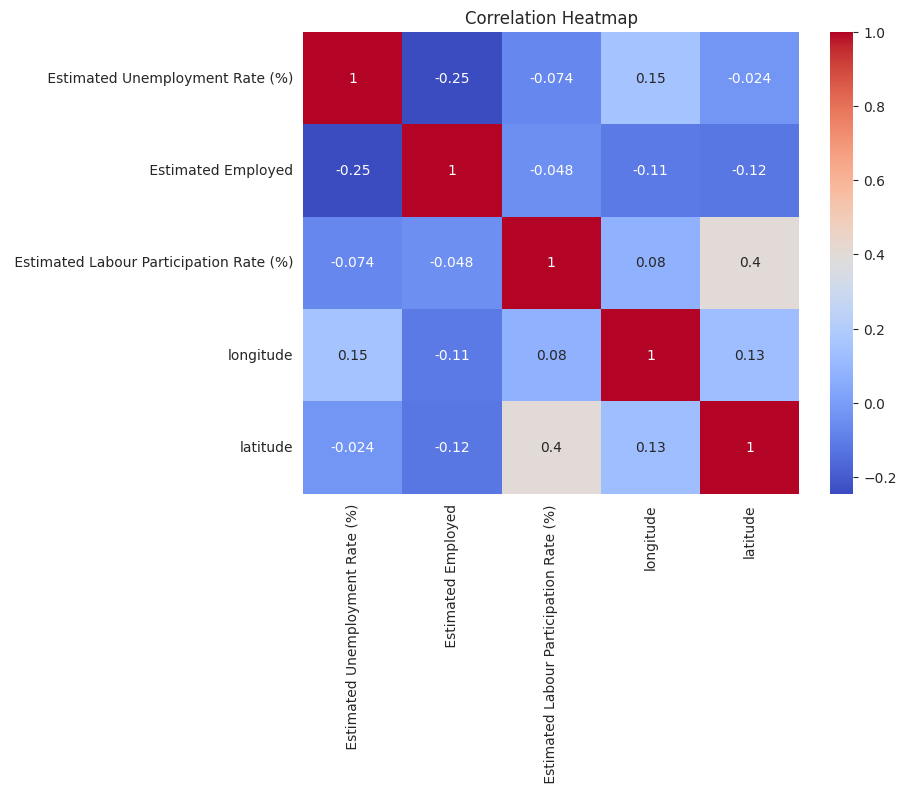


Available Columns:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [ ]:
# ==========================================================
# SALES PREDICTION USING MACHINE LEARNING
# ==========================================================

# Install if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import zipfile
import os

from google.colab import files

# ==========================================================
# UPLOAD DATASET (CSV OR ZIP)
# ==========================================================

print("Upload Sales Dataset (CSV or ZIP)")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Load ZIP
if file_name.endswith(".zip"):

    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall("dataset")

    csv_file = None

    for root, dirs, files_list in os.walk("dataset"):
        for file in files_list:
            if file.endswith(".csv"):
                csv_file = os.path.join(root, file)
                break

    df = pd.read_csv(csv_file)

# Load CSV
elif file_name.endswith(".csv"):

    df = pd.read_csv(file_name)

else:
    raise Exception("Please upload CSV or ZIP file")

# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("\nDataset Loaded Successfully!")
print(df.head())

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================================
# CLEAN DATA
# ==========================================================

df.dropna(inplace=True)

# Remove unwanted index column if exists
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================================
# FIND TARGET COLUMN
# ==========================================================

possible_targets = [
    "Sales",
    "sales",
    "Sale",
    "sale"
]

target = None

for col in possible_targets:
    if col in df.columns:
        target = col
        break

# If not found ask user
if target is None:

    print("\nAvailable Columns:")
    print(df.columns.tolist())

    target = input(
        "\nEnter target column name exactly as shown above: "
    )

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = df.drop(target, axis=1)

y = df[target]

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# TRAIN MODEL
# ==========================================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed!")

# ==========================================================
# PREDICTIONS
# ==========================================================

predictions = model.predict(X_test)

# ==========================================================
# EVALUATION
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("\n========== MODEL PERFORMANCE ==========")

print("MAE :", round(mae, 4))

print("MSE :", round(mse, 4))

print("RMSE :", round(rmse, 4))

print("R² Score :", round(r2, 4))

# ==========================================================
# ACTUAL VS PREDICTED
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.Series(
    model.coef_,
    index=X.columns
)

importance.sort_values().tail(10).plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Top Features Affecting Sales")

plt.show()

# ==========================================================
# SAMPLE PREDICTIONS
# ==========================================================

results = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": predictions
})

print("\nSample Predictions:")

print(results.head(10))

# ==========================================================
# CUSTOM PREDICTION
# ==========================================================

print("\n========== CUSTOM SALES PREDICTION ==========")

new_data = {}

for col in X.columns:
    value = float(input(f"Enter value for {col}: "))
    new_data[col] = value

new_df = pd.DataFrame([new_data])

prediction = model.predict(new_df)

print("\nPredicted Sales:", round(prediction[0], 2))

# ==========================================================
# INSIGHTS
# ==========================================================

print("\n========== INSIGHTS ==========")

print("1. Advertising expenditure directly impacts sales.")
print("2. Some channels contribute more than others.")
print("3. The model can forecast future sales.")
print("4. Businesses can optimize ad spending using predictions.")

print("\n========== PROJECT COMPLETED ==========")